In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

# Paths (house convention: notebook lives in notebooks/, root is parent)
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data"
PHASE3_DIR = DATA_DIR / "phase3"
PHASE5_FIG = PROJECT_ROOT / "results" / "phase5" / "figures"
PHASE5_TAB = PROJECT_ROOT / "results" / "phase5" / "tables"
PHASE3_TAB = PROJECT_ROOT / "results" / "phase3" / "tables"

# Cross-venue outputs (Phase 6 of main.py)
wedge_md   = pd.read_csv(PHASE5_TAB / "matched_difference_regressions.csv")
panel_dk   = pd.read_csv(PHASE5_TAB / "panel_regressions_dk.csv")
regional   = pd.read_csv(PHASE5_TAB / "regional_mfk_summary.csv")

# Extension 1 (inverse-contract) + joint regime test
inv_wedge  = pd.read_csv(PHASE5_TAB / "inverse_contract_wedge.csv")
inv_daily  = pd.read_csv(PHASE5_TAB / "inverse_contract_daily.csv")
joint      = pd.read_csv(PHASE3_TAB / "joint_regime_test_crypto.csv")
joint_det  = pd.read_csv(PHASE3_TAB / "joint_regime_detail_crypto.csv")

#### 1. Cross-venue cumulant-premium wedge (matched-difference)


In [3]:
venue_wedge = wedge_md[wedge_md["regressor"] == "const (venue wedge)"].copy()
display(venue_wedge[["dep_var", "coef", "se", "t_stat", "p_value", "stars"]]
        .reset_index(drop=True))

# State interactions: confirm none significant (the wedge is a level effect)
inter = wedge_md[wedge_md["regressor"].isin(["Z_IVS_1", "rv", "fng"])]
print("State interactions (should all be insignificant -> constant level wedge):")
for dv in ["Pi_2", "Pi_3", "Pi_4"]:
    sub = inter[inter["dep_var"] == dv]
    sig = (sub["p_value"] < 0.05).any()
    print(f"  {dv}: any state interaction significant at 5%? {bool(sig)}")

,dep_var,coef,se,t_stat,p_value,stars
0,Pi_2,0.003567,0.000417,8.563973,1.090429e-17,***
1,Pi_3,0.001957,0.000573,3.417222,6.326374e-04,***
2,Pi_4,0.003260,0.001039,3.139037,1.695042e-03,***


State interactions (should all be insignificant -> constant level wedge):
  Pi_2: any state interaction significant at 5%? False
  Pi_3: any state interaction significant at 5%? False
  Pi_4: any state interaction significant at 5%? False


#### 2. Conditional / regional MFK by volatility tercile (95% bootstrap bands)

,regime,n_days,mean_down,lo_down,hi_down,mean_mid,lo_mid,hi_mid,mean_up,lo_up,hi_up
0,unconditional,619,-0.0307,-0.0416,-0.0209,0.0069,0.0045,0.0093,-0.0826,-0.1180,-0.0565
1,low,223,-0.0296,-0.0553,-0.0104,0.0023,-0.0004,0.0049,-0.1037,-0.2052,-0.0352
2,mid,191,-0.0318,-0.0458,-0.0198,0.0062,0.0045,0.0082,-0.0733,-0.0969,-0.0500
3,high,205,-0.0309,-0.0376,-0.0230,0.0124,0.0099,0.0145,-0.0682,-0.0826,-0.0481


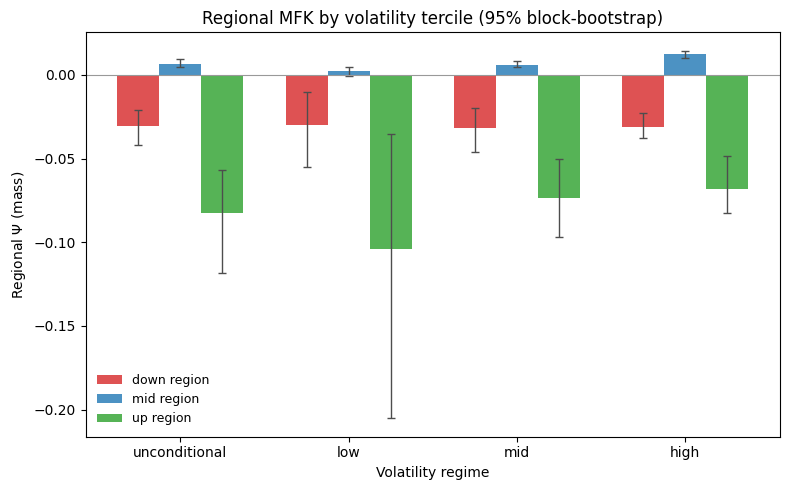

In [4]:
display(regional[["regime", "n_days", "mean_down", "lo_down", "hi_down",
                  "mean_mid", "lo_mid", "hi_mid",
                  "mean_up", "lo_up", "hi_up"]].round(4))

fig, ax = plt.subplots(figsize=(8, 5))
regimes = regional["regime"].tolist()
x = np.arange(len(regimes))
w = 0.25
for k, (reg, col) in enumerate([("down", "C3"), ("mid", "C0"), ("up", "C2")]):
    m = regional[f"mean_{reg}"].values
    lo = regional[f"lo_{reg}"].values
    hi = regional[f"hi_{reg}"].values
    ax.bar(x + (k-1)*w, m, w, color=col, alpha=0.8, label=f"{reg} region")
    ax.errorbar(x + (k-1)*w, m, yerr=[m-lo, hi-m], fmt="none",
                ecolor="0.3", capsize=3, lw=1)
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(regimes)
ax.set_ylabel(r"Regional $\Psi$ (mass)"); ax.set_xlabel("Volatility regime")
ax.set_title("Regional MFK by volatility tercile (95% block-bootstrap)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

#### 3. Extension 1 — Inverse-contract numeraire prediction

Deribit is coin-margined (inverse) -> BTC-numeraire measure = unit Esscher tilt of the CME density. Parameter-free predicted wedge vs measured wedge. **Predicted negative, measured positive at every order: contract design predicts the wrong sign.**

,cumulant,predicted_wedge,pred_ci_lo,pred_ci_hi,measured_wedge,meas_ci_lo,meas_ci_hi,residual
0,Pi_2,-0.00367,-0.00512,-0.00230,0.00292,0.00204,0.00384,0.00659
1,Pi_3,-0.01599,-0.02068,-0.01200,0.00091,0.00053,0.00131,0.01690
2,Pi_4,-0.00374,-0.00529,-0.00222,0.00139,0.00075,0.00203,0.00513


Sign agreement: 0/3 cumulants.
Contract design predicts the WRONG sign -> the friction is real and amplified (residual > measured at every order).


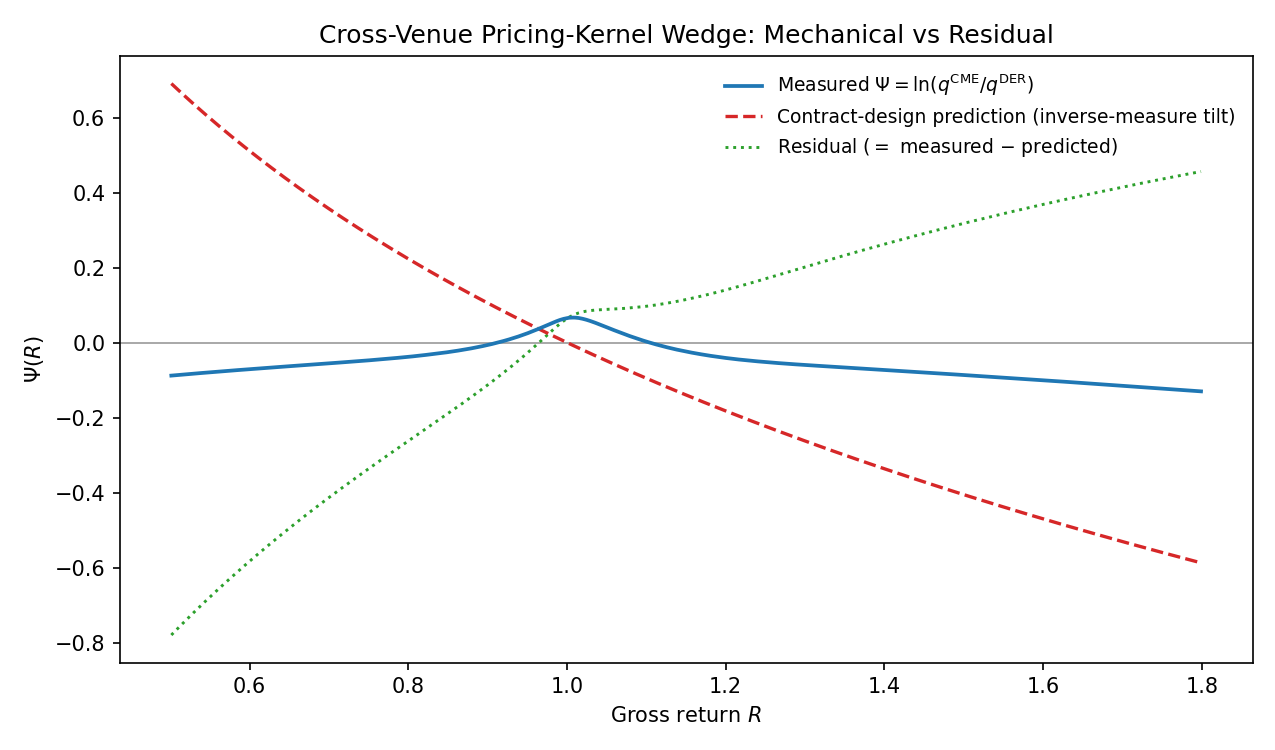

In [5]:
display(inv_wedge[["cumulant", "predicted_wedge", "pred_ci_lo", "pred_ci_hi",
                   "measured_wedge", "meas_ci_lo", "meas_ci_hi", "residual"]].round(5))

agree = int(np.sum(np.sign(inv_wedge["predicted_wedge"]) ==
                   np.sign(inv_wedge["measured_wedge"])))
print(f"Sign agreement: {agree}/{len(inv_wedge)} cumulants.")
print("Contract design predicts the WRONG sign -> the friction is real and "
      "amplified (residual > measured at every order).")

# The Psi overlay decomposition figure (mechanical vs residual)
img = PHASE5_FIG / "fig_inverse_contract_psi.png"
if img.exists():
    display(Image(filename=str(img)))
else:
    print(f"[figure not found: run run_inverse_contract.py] {img}")

#### 4. Joint regime test (Phase 3 follow-up)

The marginal curvature c is collinear (insignificant per-tercile), so the joint test of H₀: (b,c,d)_low = (b,c,d)_high is the correct question. **Significant at both venues; the low-vol kernel is more concave at the money (2c+6d).**

In [6]:
display(joint[["venue", "wald_stat", "p_value",
               "delta_b", "delta_c", "delta_d", "frac_vector_consistent"]].round(4))

curv = joint_det[joint_det["test"] == "curv_at_money_diff"]
print("Curvature at money (2c+6d at R=1), low - high:")
for _, r in curv.iterrows():
    print(f"  {r['venue']}: {r['diff_point']:+.2f} "
          f"[{r['ci_lo']:+.2f}, {r['ci_hi']:+.2f}]  P(<0) = {r['frac_negative']:.3f}")
print("\nThe kernel significantly depends on the volatility regime; the low-vol "
      "kernel is significantly more concave at the money (P<0 = 1.000 both venues).")

,venue,wald_stat,p_value,delta_b,delta_c,delta_d,frac_vector_consistent
0,CME,32.9016,0.005,15.8425,-7.6535,0.0587,0.460
1,DER,20.3802,0.010,17.1939,-9.3011,0.6724,0.655


Curvature at money (2c+6d at R=1), low - high:
  CME: -14.95 [-24.27, -10.41]  P(<0) = 1.000
  DER: -14.57 [-22.78, -9.65]  P(<0) = 1.000

The kernel significantly depends on the volatility regime; the low-vol kernel is significantly more concave at the money (P<0 = 1.000 both venues).


---
**Summary.** The cross-venue wedge is positive and significant at every cumulant
order (a constant level effect, no state interactions); contract design predicts
the opposite sign, so the friction is real and amplified; the kernel's
regime-dependence is jointly significant via the at-money curvature. The recurring
theme: cross-venue *differences* are precisely estimated where single-venue *levels*
are not.